# 04 - Statistical Correlation: Meeting Hours vs. Productivity & Burnout

This notebook tests, rather than eyeballs, whether weekly time spent in
meetings is associated with self-reported productivity and burnout.

**Input:** `data/processed/pulse_clean.csv` — weekly employee pulse survey
data (columns used: `hours_in_meetings`, `self_reported_productivity`,
`self_reported_burnout`, `seniority`).

**Methods:**
1. Pearson correlation (`scipy.stats.pearsonr`) — hours vs. productivity,
   and separately hours vs. burnout.
2. OLS regression (`statsmodels`) — productivity on hours, controlling for
   seniority as a categorical variable (fixed effect).
3. Scatter + trendline chart — `hours_in_meetings` vs.
   `self_reported_productivity`.

**Output:** `images/productivity_vs_hours.png`

**Important framing up front:** every result below is *correlational*. This
notebook cannot and does not claim that meetings *cause* lower productivity
or higher burnout — see the closing markdown cell for why, and what a real
causal test would require.


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import pearsonr

sns.set_theme(style="whitegrid")

PROCESSED_DIR = Path("../data/processed")
IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

pulse = pd.read_csv(PROCESSED_DIR / "pulse_clean.csv")

cols = ["hours_in_meetings", "self_reported_productivity", "self_reported_burnout", "seniority"]
pulse = pulse[cols].dropna()

print(f"pulse_weekly: {len(pulse):,} rows after dropping incomplete records")
print(pulse["seniority"].value_counts())
pulse.describe()


pulse_weekly: 84,500 rows after dropping incomplete records
seniority
junior     44720
mid        28080
senior      9490
manager     2210
Name: count, dtype: int64


,hours_in_meetings,self_reported_productivity,self_reported_burnout
count,84500.000000,84500.000000,84500.000000
mean,7.851704,6.973314,3.038757
std,3.942976,0.582579,0.597850
min,0.000000,4.000000,1.000000
25%,5.190000,7.000000,3.000000
50%,7.090000,7.000000,3.000000
75%,9.690000,7.000000,3.000000
max,34.880000,9.000000,8.000000


## 1) Pearson correlation

In [2]:
r_productivity, p_productivity = pearsonr(pulse["hours_in_meetings"], pulse["self_reported_productivity"])
r_burnout, p_burnout = pearsonr(pulse["hours_in_meetings"], pulse["self_reported_burnout"])

correlation_results = pd.DataFrame(
    {
        "outcome": ["self_reported_productivity", "self_reported_burnout"],
        "pearson_r": [round(r_productivity, 4), round(r_burnout, 4)],
        "p_value": [p_productivity, p_burnout],
        "n": [len(pulse), len(pulse)],
    }
)
correlation_results


,outcome,pearson_r,p_value,n
0,self_reported_productivity,-0.1569,0.0,84500
1,self_reported_burnout,0.1975,0.0,84500


**Result:** `hours_in_meetings` is weakly **negatively** correlated with
`self_reported_productivity` (Pearson r ≈ **-0.157**, p < 0.001) and weakly
**positively** correlated with `self_reported_burnout` (r ≈ **+0.197**,
p < 0.001). Both are statistically significant given the large sample size
(~84.5K weekly records), but the effect sizes are small — hours in meetings
explain only a modest slice of the variation in either outcome. In plain
English: employees who spend more hours in meetings tend to self-report
somewhat lower productivity and somewhat higher burnout, but meeting load is
clearly not the only (or even the dominant) driver of either.

## 2) OLS regression: productivity on hours, controlling for seniority

In [3]:
model = smf.ols(
    "self_reported_productivity ~ hours_in_meetings + C(seniority)",
    data=pulse,
).fit()

print(model.summary())


                                OLS Regression Results                                
Dep. Variable:     self_reported_productivity   R-squared:                       0.037
Model:                                    OLS   Adj. R-squared:                  0.037
Method:                         Least Squares   F-statistic:                     802.4
Date:                        Mon, 10 Aug 2026   Prob (F-statistic):               0.00
Time:                                00:09:31   Log-Likelihood:                -72670.
No. Observations:                       84500   AIC:                         1.454e+05
Df Residuals:                           84495   BIC:                         1.454e+05
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

**Result:** after controlling for seniority (categorical, `junior` as the
reference level), each additional weekly hour in meetings is associated with
a **-0.0185** point drop in self-reported productivity (on a 1-10 scale),
and this coefficient is highly significant (p < 0.001, t ≈ -24.3). So the
negative relationship from the raw Pearson correlation holds up even after
accounting for seniority differences — it isn't simply an artifact of, say,
managers having both more meetings and different baseline productivity.

That said, the model's **R² is only 0.037** — hours in meetings and
seniority together explain under 4% of the variance in self-reported
productivity. "Statistically significant" here means "real relationship,
not noise," not "the main story." Practically: going from a light meeting
week (~5 hrs) to a heavy one (~20 hrs) predicts roughly a 0.28-point drop in
productivity (15 hrs × -0.0185) — a small but non-trivial nudge at scale
across thousands of employee-weeks.

## 3) Chart: hours in meetings vs. productivity

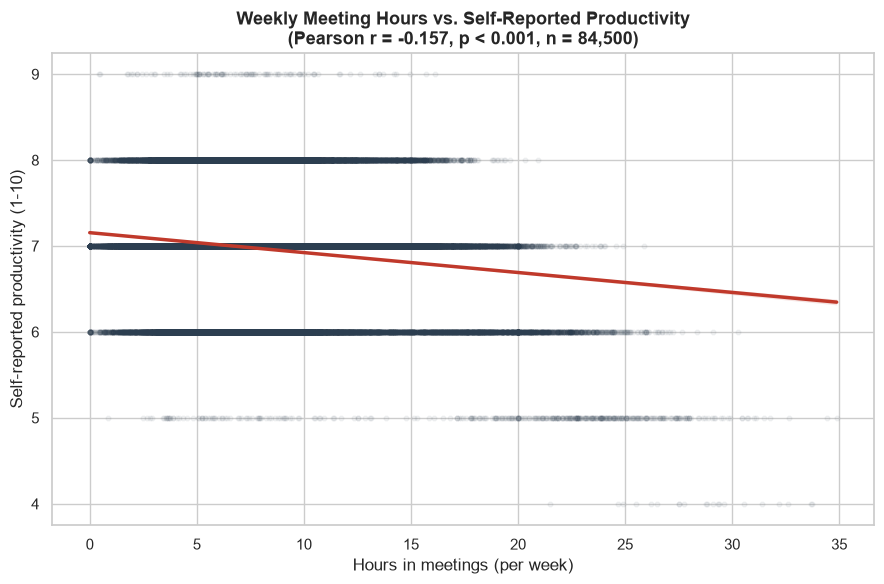

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(
    data=pulse,
    x="hours_in_meetings",
    y="self_reported_productivity",
    scatter_kws={"alpha": 0.05, "s": 12, "color": "#2c3e50"},
    line_kws={"color": "#c0392b", "linewidth": 2.5},
    ax=ax,
)
ax.set_title(
    f"Weekly Meeting Hours vs. Self-Reported Productivity\n(Pearson r = {r_productivity:.3f}, p < 0.001, n = {len(pulse):,})",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Hours in meetings (per week)")
ax.set_ylabel("Self-reported productivity (1-10)")
fig.tight_layout()
fig.savefig(IMAGES_DIR / "productivity_vs_hours.png", dpi=150)
plt.show()


## Interpretation: correlation, not causation

**What we can say:** there is a small but statistically significant
negative association between weekly meeting hours and self-reported
productivity (r ≈ -0.157), and a small positive association with burnout
(r ≈ +0.197), that survives controlling for seniority in the regression.

**What we cannot say:** that cutting meeting hours *causes* productivity to
go up or burnout to go down. This is observational, cross-sectional survey
data, so several alternative explanations remain fully consistent with the
same numbers:
- **Reverse causation:** employees who are already less productive or more
  burned out may get pulled into more meetings (e.g. to be managed more
  closely, or to compensate for slower individual output), not the other
  way around.
- **Confounding variables:** role intensity, team size, project deadlines,
  or manager style could independently drive both meeting load and
  self-reported wellbeing, creating a correlation with no direct link
  between the two.
- **Self-report bias:** productivity and burnout are both self-rated in the
  same survey as meeting hours, so mood or response-style effects at the
  time of the survey could inflate the association artificially.

**What a real causal test would look like:** a randomized (or
quasi-randomized) intervention — for example, an **A/B test** where a subset
of comparable teams (matched on department, seniority mix, and baseline
meeting load) has their recurring meetings cut by a fixed amount (e.g. -30%
of weekly meeting hours) for 8-12 weeks, while a matched control group keeps
their normal schedule. Comparing the *change* in self-reported productivity
and burnout between the treatment and control groups (a difference-in-
differences design) would isolate the effect of meeting load itself from
all the confounders above — because both groups experience the same time
period, business conditions, and survey instrument, and only meeting load
differs by design rather than by choice.

## Summary

- Pearson r (hours vs. productivity): **-0.157** (p < 0.001, n ≈ 84,500)
- Pearson r (hours vs. burnout): **+0.197** (p < 0.001, n ≈ 84,500)
- OLS coefficient on `hours_in_meetings` (controlling for seniority):
  **-0.0185** productivity points per hour (p < 0.001), model R² = 0.037
- Chart saved: `images/productivity_vs_hours.png`
- Relationship is real but weak, and correlational only — see interpretation
  cell above for the proposed A/B test design to establish causality.
